# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [1]:
from pathlib import Path

import pandas as pd

ROOT_DIR = Path().resolve().parent
DATA_DIR = ROOT_DIR / "data/raw"
file_path = 'Telco_customer_churn.csv'
data_path = DATA_DIR / file_path

df = pd.read_csv(data_path)
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


- ¿Cuántas filas y columnas tiene el dataframe?

In [2]:
df.shape

(7043, 33)

El dataframe tiene 7043 filas y 33 columnas

- ¿De qué tipo de dato es cada columna?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

- ¿Las variables están en el tipo de dato correcto para su contenido?

In [4]:
df[['Total Charges']]

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


Revisando la información proporcionada por IBM del dataset, podemos observar que la columna Total Charge, que no smuestra la suma de los pagos de los clientes, pandas nos la toma como un objeto pero en realidad debería ser un float por los datos que podemos ver contiene la columna, así que debemos cambiar el tipo.

In [5]:
df = pd.read_csv(
    data_path,
    na_values=[' ']
    )

df.head()

df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

Aquí no pudimos convertirlo directamente porque se encontraban valores con espacio (' ') que pandas no reconocía como un valor nulo, así que estos espacio los convertimos a NaN en la lectura del dataset y ya de esta manera la columna toma el tipo float64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [7]:
df.describe() #Variables cuantitativas

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


- No parece haber valores imposibles para las variables numéricas.
- La variable **Count** toma un solo valor (porque su variación estandar std=0)
- La varible **Churn Value** es una variable cualitativa, porque solo toma 2 valores(Esto se refleja en min, max y los cuartiles).

In [8]:
df.describe(include='object').T #Variables cualitativas

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


- La variable **CustomerID** es una clave primaria porque de 7043 registros, 7043 son únicos
- Las variables **Country** y **State** solo toman un valor, es decir que son constantes
- Las variables **City** y **Lat Long** tienen alta cardinalidad

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [9]:
cat_cols = df.drop(['CustomerID', 'Country', 'State', 'City', 'Lat Long'], axis=1).select_dtypes(include=['object']).columns

In [10]:
df.isnull().sum().sort_values(ascending=False).head()

Churn Reason     5174
Total Charges      11
CustomerID          0
Count               0
Country             0
dtype: int64

Las variables **Churn Reason** y **Total Charges** tienen datos nulos

In [11]:
nulos = df.isnull().sum()/df.shape[0]*100
nulos.sort_values(ascending=False).head()

Churn Reason     73.463013
Total Charges     0.156183
CustomerID        0.000000
Count             0.000000
Country           0.000000
dtype: float64

- El 73.46% de registros de la variable **Churn Reason** tienen datos nulos
- El 0.16% de registros de la variable **Total Charges** tienen datos nulos

In [12]:
print('Duplicados: ', df.duplicated().sum())

Duplicados:  0


No hay registros duplicados en el dataset

La única variable con problemas de formateo era Total Charges pero ya se solucionó

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

array([[<Axes: title={'center': 'Zip Code'}>,
        <Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>],
       [<Axes: title={'center': 'Tenure Months'}>,
        <Axes: title={'center': 'Monthly Charges'}>,
        <Axes: title={'center': 'Total Charges'}>],
       [<Axes: title={'center': 'Churn Score'}>,
        <Axes: title={'center': 'CLTV'}>, <Axes: >]], dtype=object)

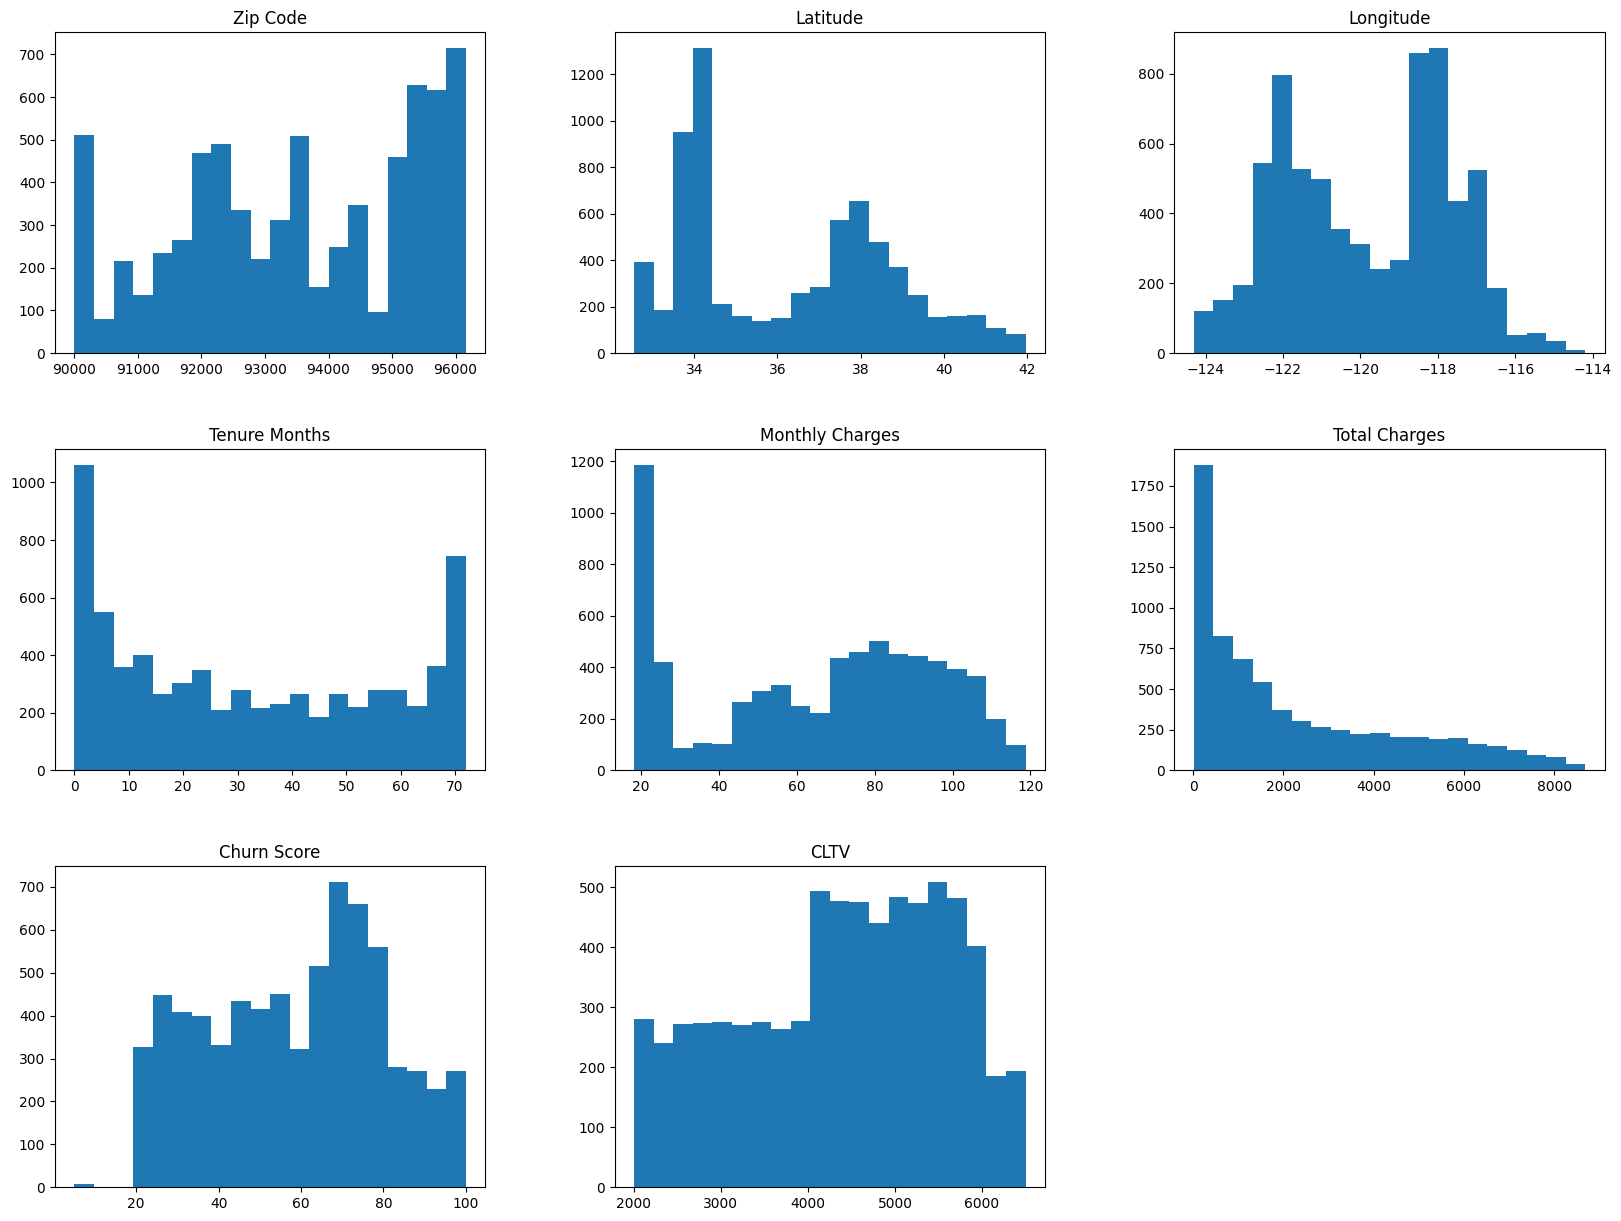

In [13]:
df.drop(['Count', 'Churn Value'], axis=1).hist(
    figsize=(20, 15),
    bins=20,
    grid=False
    )

En las gráficas no podemos ver la forma dde una normal pero para corroborar vamos a hacer una prueba de bondad de ajuste

In [14]:
from scipy.stats import kstest

num_vars = df.select_dtypes(include=["number"]).columns

for num in num_vars:
    __, p_value = kstest(df[num], 'norm', args=(df[num].mean(), df[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para Count:
  Valor p: nan
  Count no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Zip Code:
  Valor p: 4.349499185284863e-89
  Zip Code no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Latitude:
  Valor p: 7.384987152439983e-206
  Latitude no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Longitude:
  Valor p: 1.9882961763379662e-110
  Longitude no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Tenure Months:
  Valor p: 4.662721654217928e-76
  Tenure Months no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Monthly Charges:
  Valor p: 3.1510583248297797e-98
  Monthly Charges no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para Total Charges:
  Valor p: nan
  Total Charges no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmo

c:\Users\USER\ap-2026-1-61\.venv\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2159: RuntimeWarning: invalid value encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)


Aqui ya se puede decir con seguridad que ninguna cumple con el supuesto de normalidad

Zip Code              Axes(0.125,0.653529;0.227941x0.226471)
Latitude           Axes(0.398529,0.653529;0.227941x0.226471)
Longitude          Axes(0.672059,0.653529;0.227941x0.226471)
Tenure Months         Axes(0.125,0.381765;0.227941x0.226471)
Monthly Charges    Axes(0.398529,0.381765;0.227941x0.226471)
Total Charges      Axes(0.672059,0.381765;0.227941x0.226471)
Churn Score               Axes(0.125,0.11;0.227941x0.226471)
CLTV                   Axes(0.398529,0.11;0.227941x0.226471)
dtype: object

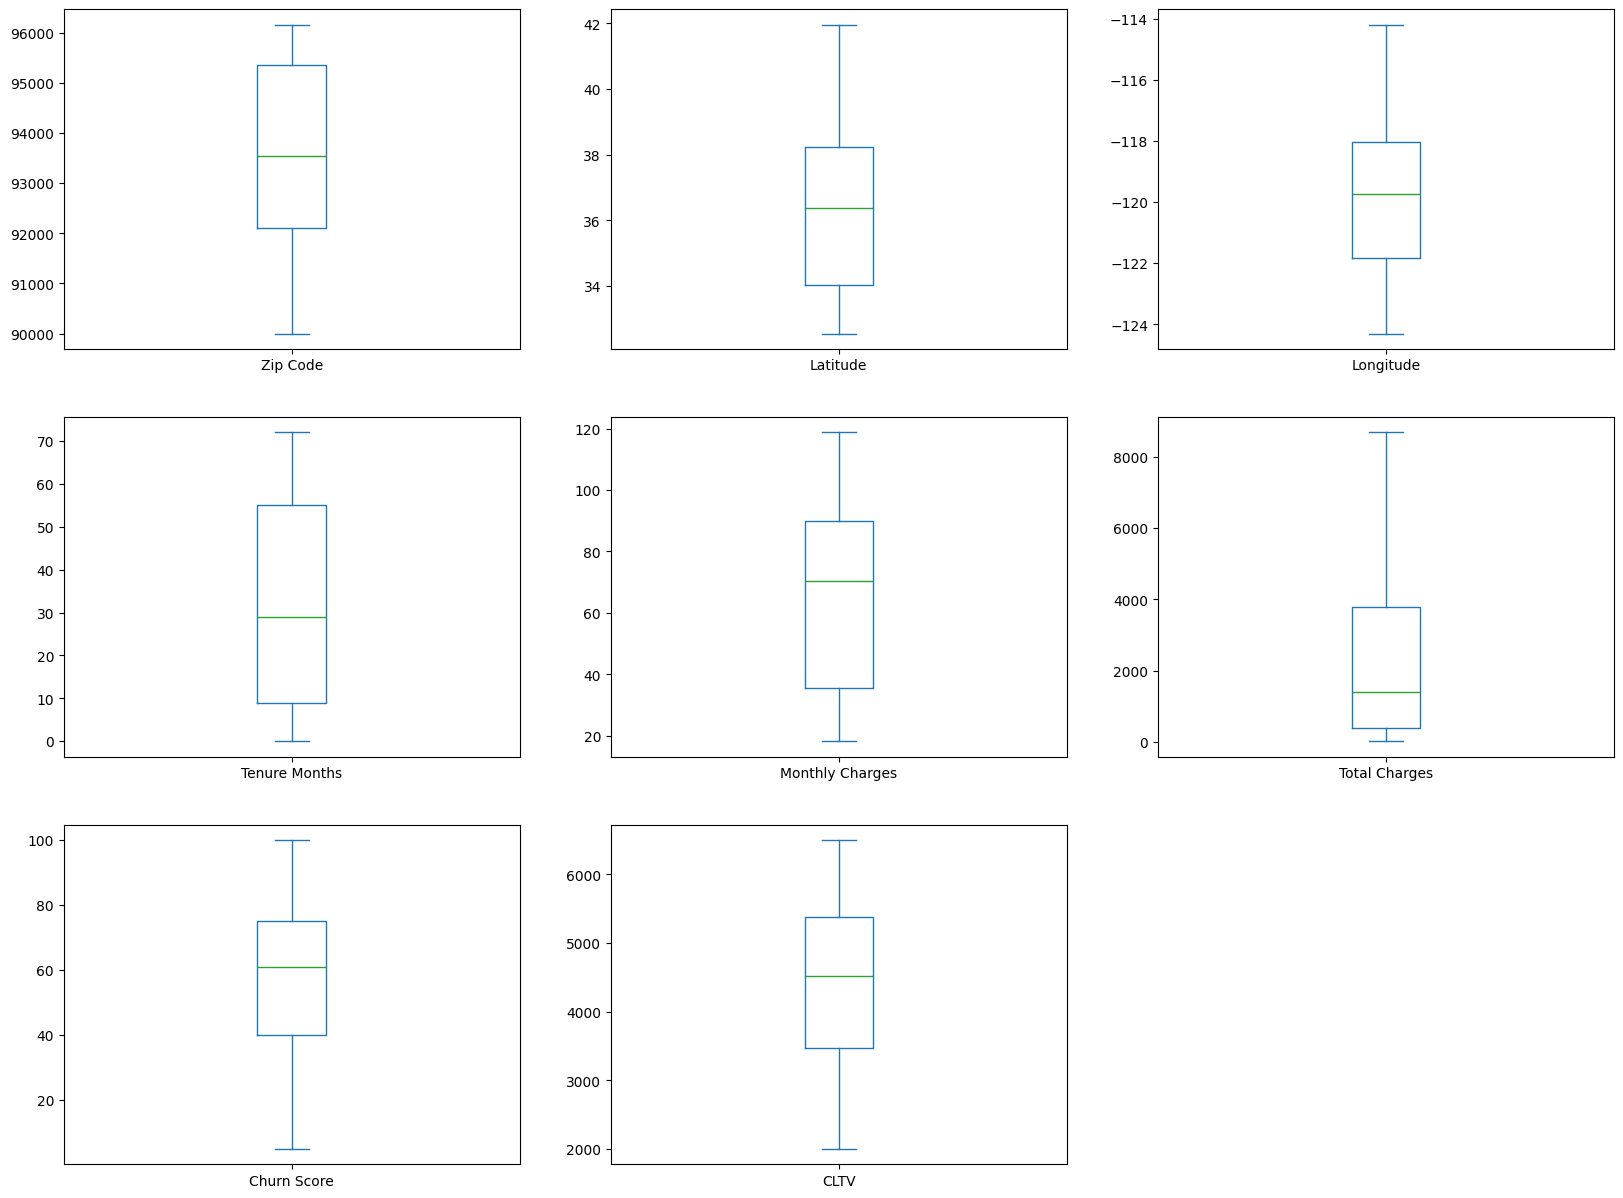

In [15]:
df.drop(['Count', 'Churn Value'], axis=1).select_dtypes(include=['int64', 'float64']).plot(
    kind='box',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

Ninguna variable cuantitativa tiene valores atípicos

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

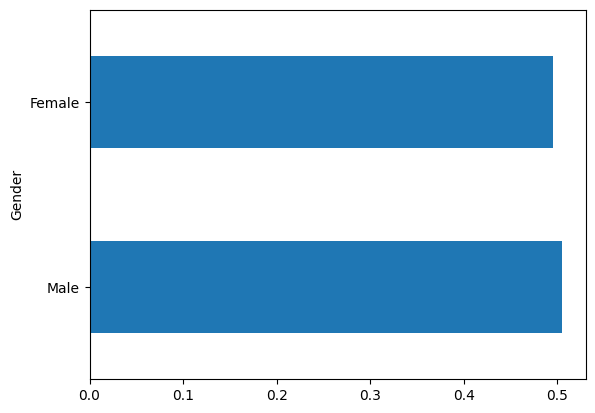

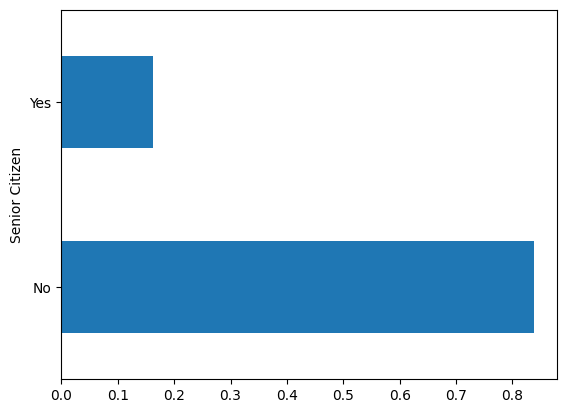

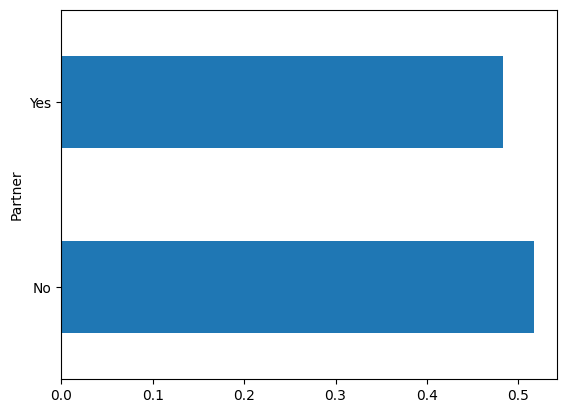

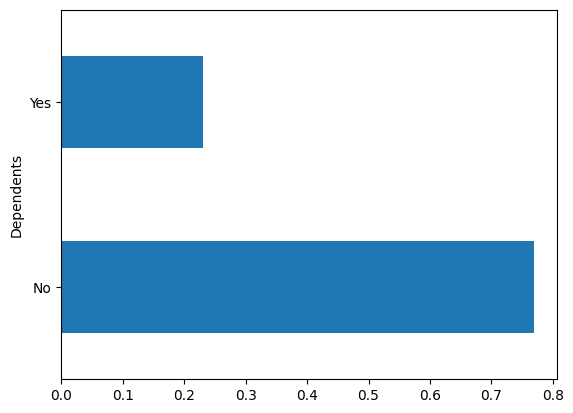

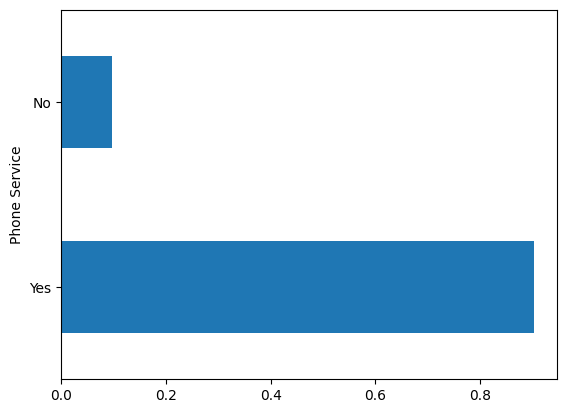

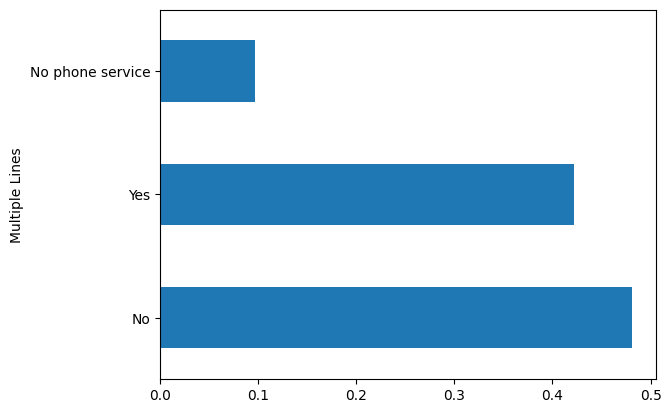

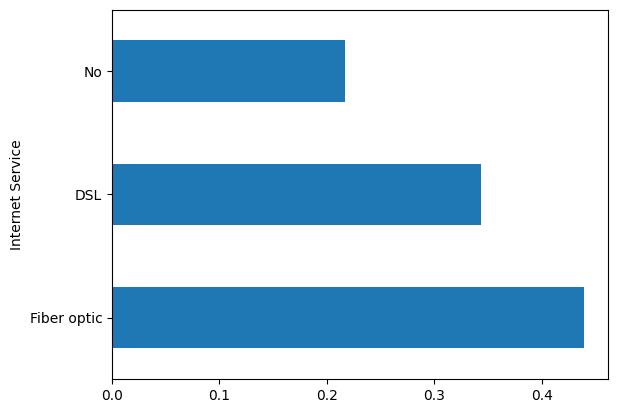

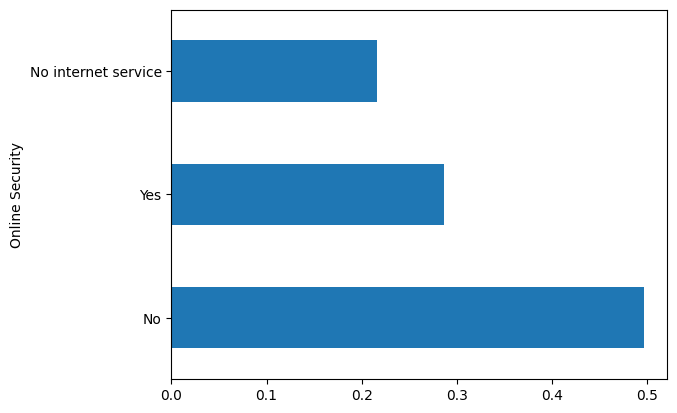

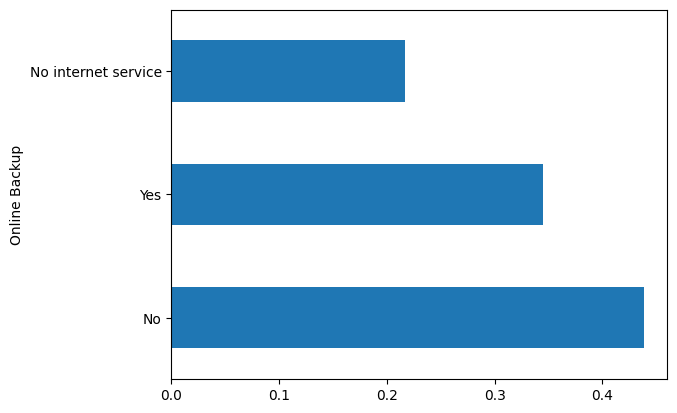

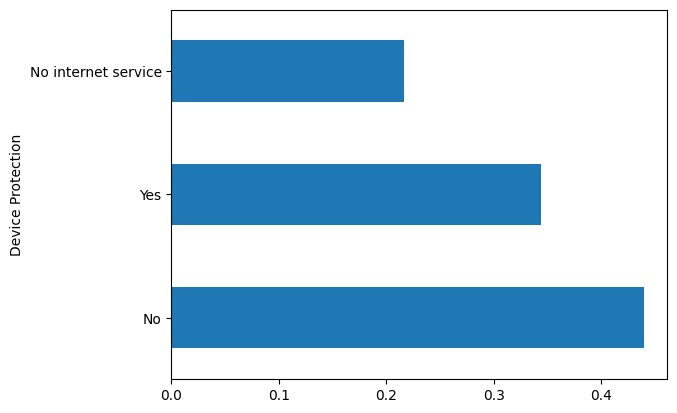

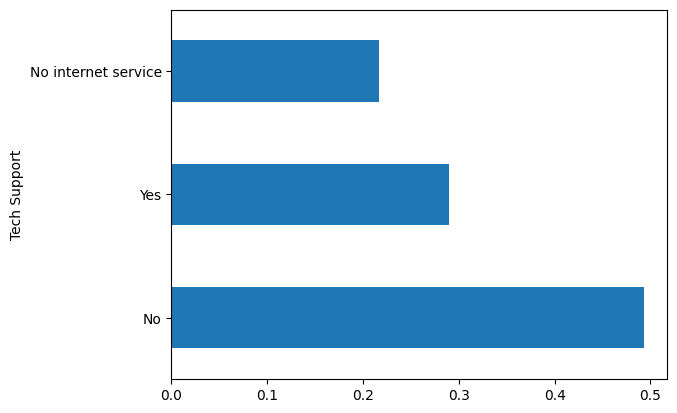

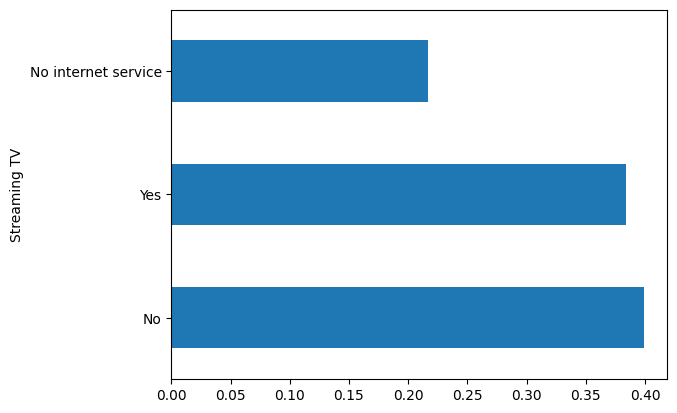

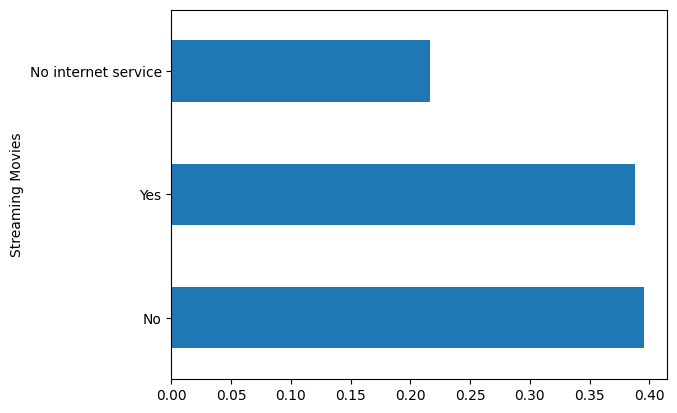

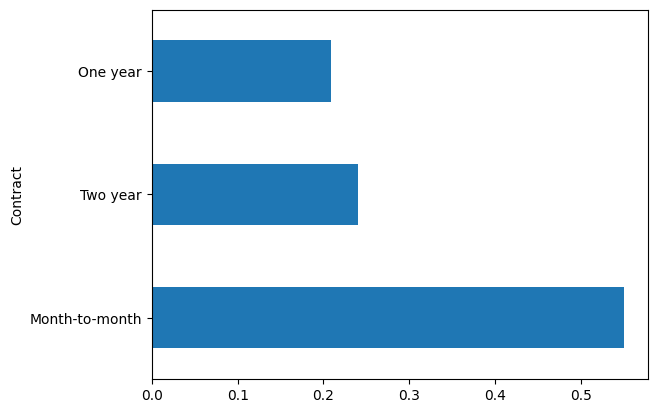

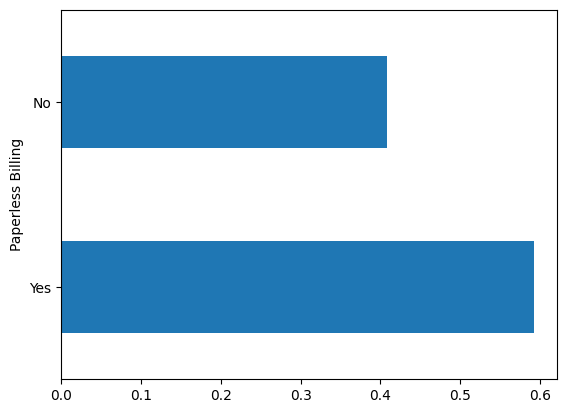

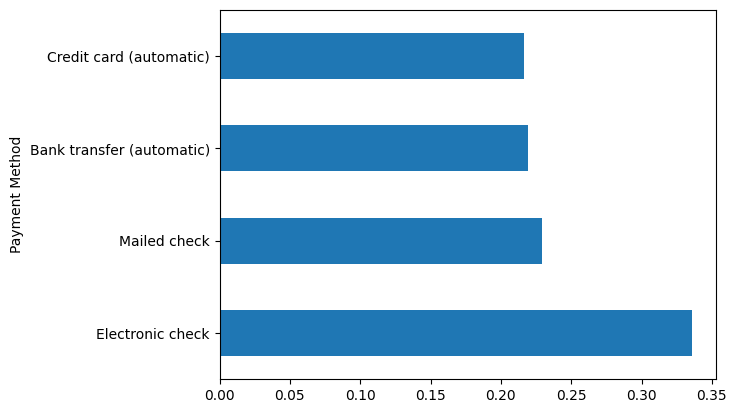

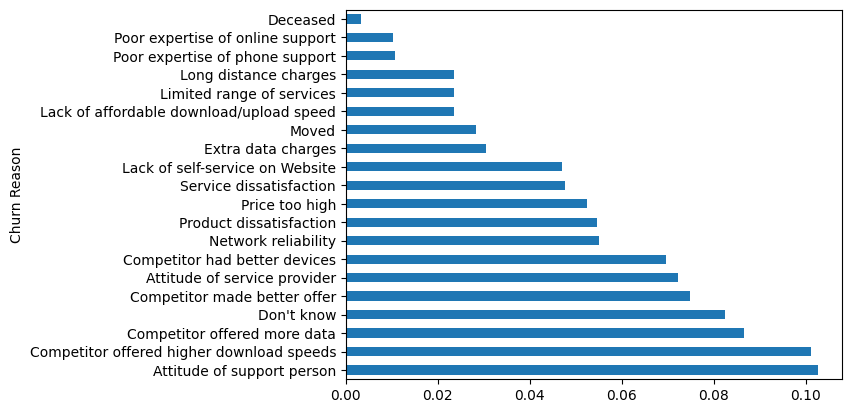

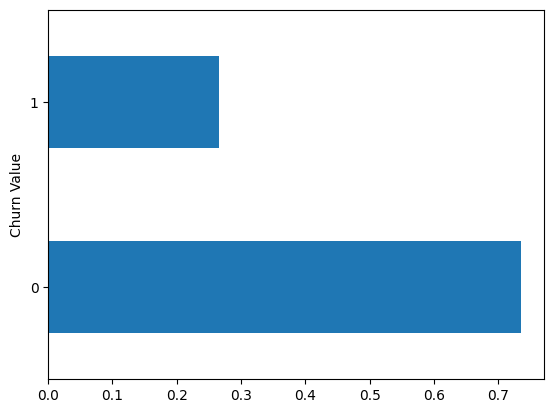

In [16]:
import matplotlib.pyplot as plt

# Se seleccionan las variables tipo objeto del dataframe y se añaden las variables Count y Churn Value porque también son cualitativas
cat_vars = list(df.select_dtypes(include=['object']).columns) + ['Churn Value']

cat_vars = [var for var in cat_vars if var not in ['City', 'Churn Label', 'CustomerID', 'Lat Long','State', 'Country']]

for var in cat_vars:
    plt.figure()
    df[var].value_counts(normalize=True).plot(kind='barh')
    plt.show();

Aquí seleccionamos las variables tipo objeto y añadimos Count y Churn Vaue porque también son variables cualitativas, eliminamos las variables que tienen alta cardinalidad

In [17]:
for var in cat_vars:
    print(f'Categorías de la variable {var}:')
    print(df[var].value_counts())
    print('\n')

Categorías de la variable Gender:
Gender
Male      3555
Female    3488
Name: count, dtype: int64


Categorías de la variable Senior Citizen:
Senior Citizen
No     5901
Yes    1142
Name: count, dtype: int64


Categorías de la variable Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64


Categorías de la variable Dependents:
Dependents
No     5416
Yes    1627
Name: count, dtype: int64


Categorías de la variable Phone Service:
Phone Service
Yes    6361
No      682
Name: count, dtype: int64


Categorías de la variable Multiple Lines:
Multiple Lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


Categorías de la variable Internet Service:
Internet Service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64


Categorías de la variable Online Security:
Online Security
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64


Categoría

La categoría Deceased de la variable **Churn Value** es atípica porque representa una frecuencia muy baja respecto al total de registros

## Paso 6: Análisis bivariado.

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la **Churn Value**.

Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecen ser buenas predictoras y cuáles no?


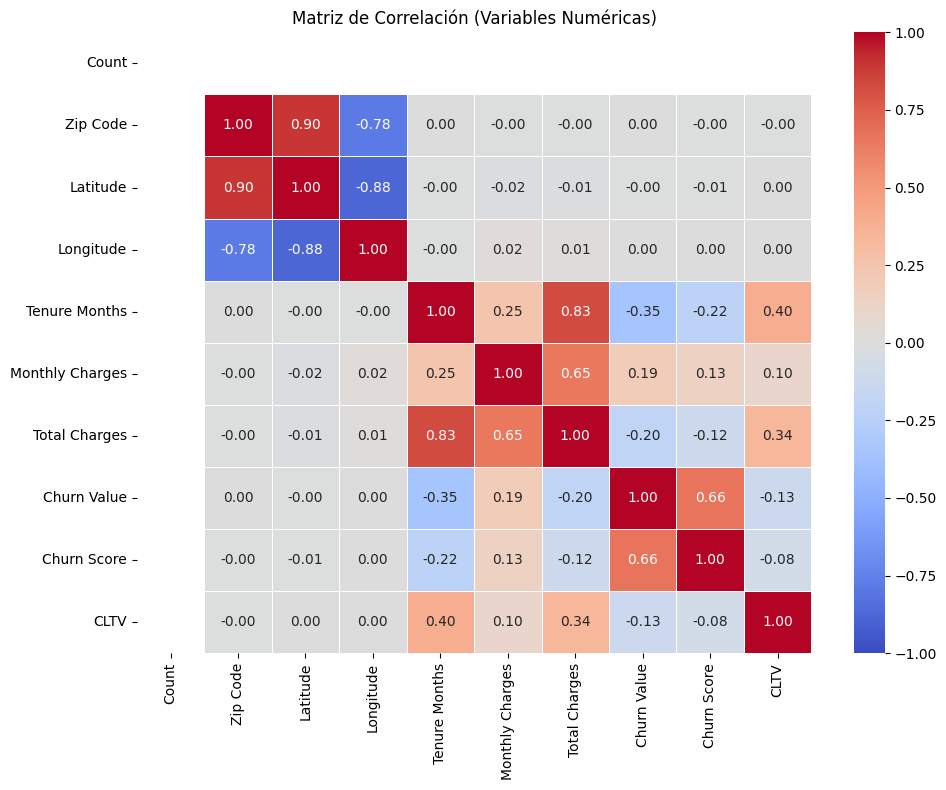

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = df.select_dtypes(include=['number']).corr()


plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación (Variables Numéricas)')
plt.tight_layout()
plt.show()


Las correlaciones más altas con la variable objetivo nos indican qué variables cuantitativas tienen una relación más clara con la probabilidad de churn.

Si la correlación es positiva, el aumento de esa variable suele asociarse a más churn; si es negativa, a menos churn.


### Relaciones entre dos variables cuantitativas

La relación entre dos variables numéricas se puede observar con un diagrama de dispersión. Esto ayuda a detectar patrones lineales o curvilíneos.


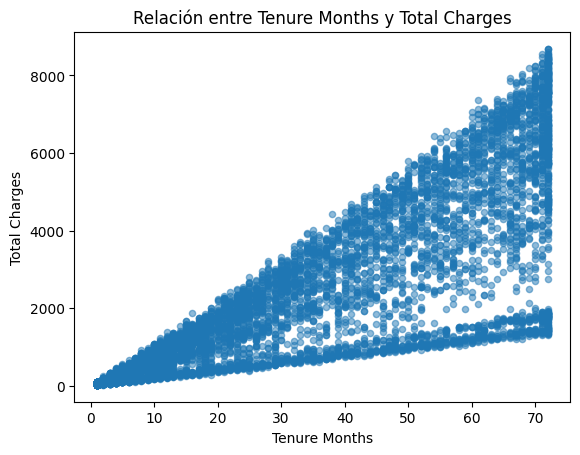

In [20]:
df.plot(kind='scatter', x='Tenure Months', y='Total Charges', alpha=0.5)
plt.title('Relación entre Tenure Months y Total Charges')
plt.show()


### Relaciones entre una variable cuantitativa y la variable objetivo

Los diagramas de caja muestran si la distribución de una variable numérica cambia según la clase de la variable objetivo.


<Figure size 700x400 with 0 Axes>

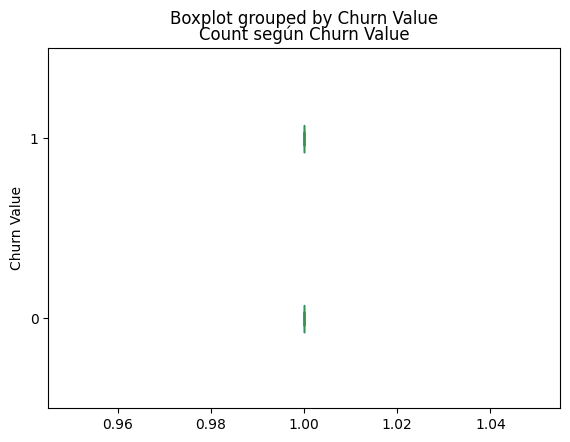

<Figure size 700x400 with 0 Axes>

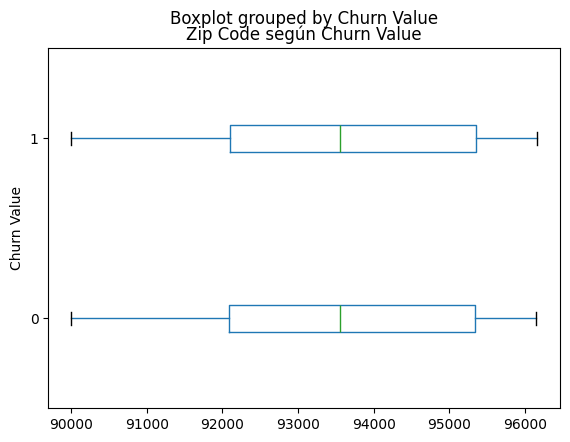

<Figure size 700x400 with 0 Axes>

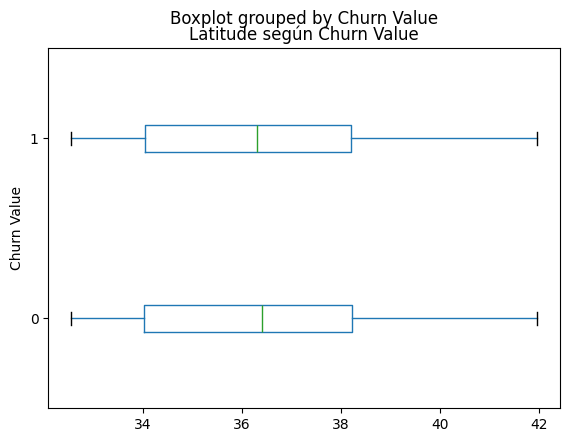

<Figure size 700x400 with 0 Axes>

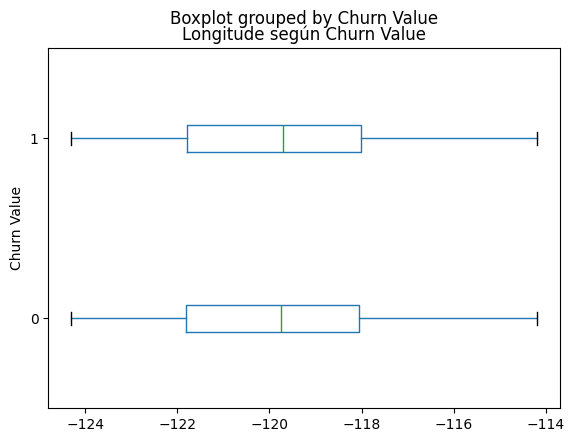

<Figure size 700x400 with 0 Axes>

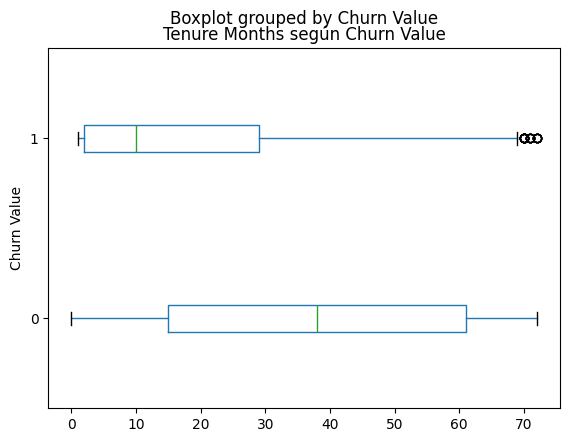

<Figure size 700x400 with 0 Axes>

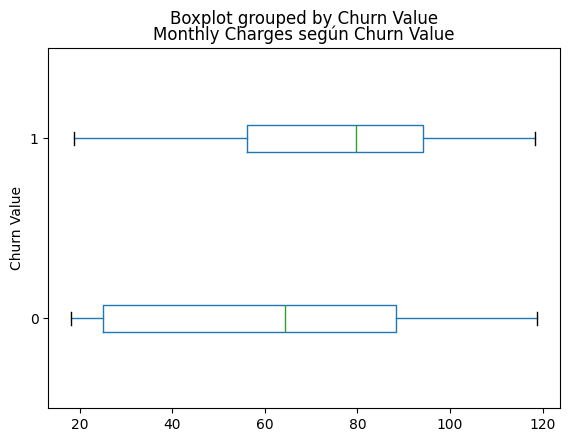

<Figure size 700x400 with 0 Axes>

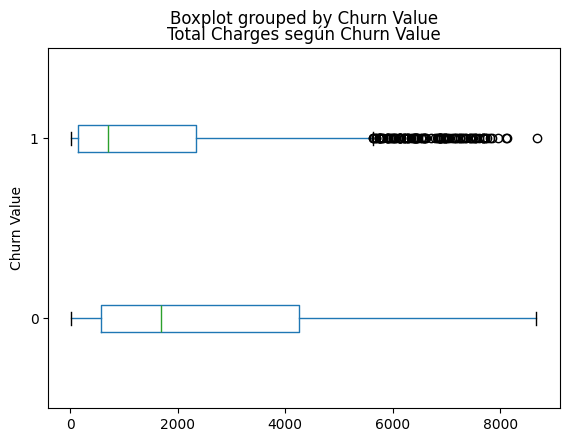

<Figure size 700x400 with 0 Axes>

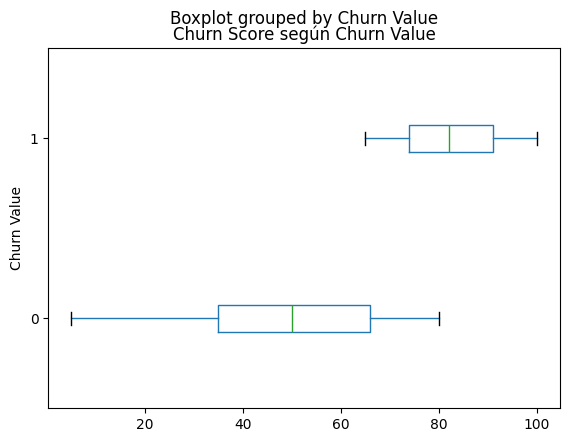

<Figure size 700x400 with 0 Axes>

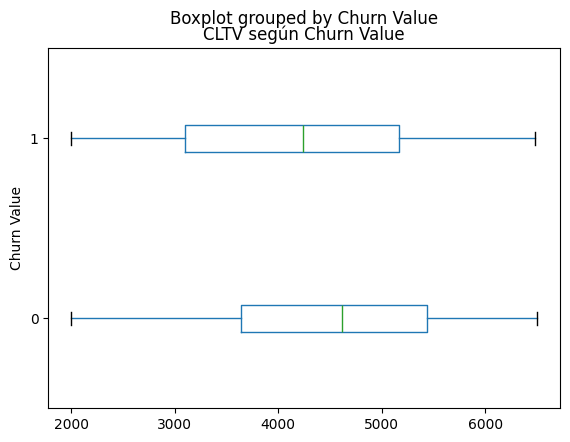

In [21]:
for var in num_vars:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=var, by='Churn Value', grid=False, vert=False)
    plt.title(f'{var} según Churn Value')
    plt.show()


### Relaciones entre variables cualitativas y la variable objetivo

Las tablas de contingencia y los gráficos de barras apiladas permiten estudiar cómo cambia la proporción de churn en cada categoría.


In [22]:
cat_vars = list(df.select_dtypes(include=['object']).columns) + ['Churn Value']
cat_vars = [var for var in cat_vars if var not in ['City', 'CustomerID', 'Lat Long', 'State', 'Country', 'Churn Label']]
cat_pred = [var for var in cat_vars if var != 'Churn Value']

for var in cat_pred:
    print(f'Proporción de churn por {var}:')
    print((pd.crosstab(df[var], df['Churn Value'], normalize='index') * 100).round(2))
    print('\n')


Proporción de churn por Gender:
Churn Value      0      1
Gender                   
Female       73.08  26.92
Male         73.84  26.16


Proporción de churn por Senior Citizen:
Churn Value         0      1
Senior Citizen              
No              76.39  23.61
Yes             58.32  41.68


Proporción de churn por Partner:
Churn Value      0      1
Partner                  
No           67.04  32.96
Yes          80.34  19.66


Proporción de churn por Dependents:
Churn Value      0      1
Dependents               
No           67.45  32.55
Yes          93.48   6.52


Proporción de churn por Phone Service:
Churn Value        0      1
Phone Service              
No             75.07  24.93
Yes            73.29  26.71


Proporción de churn por Multiple Lines:
Churn Value           0      1
Multiple Lines                
No                74.96  25.04
No phone service  75.07  24.93
Yes               71.39  28.61


Proporción de churn por Internet Service:
Churn Value           0      1


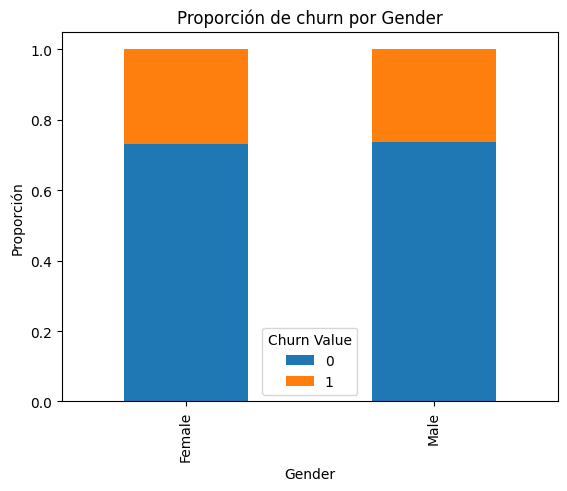

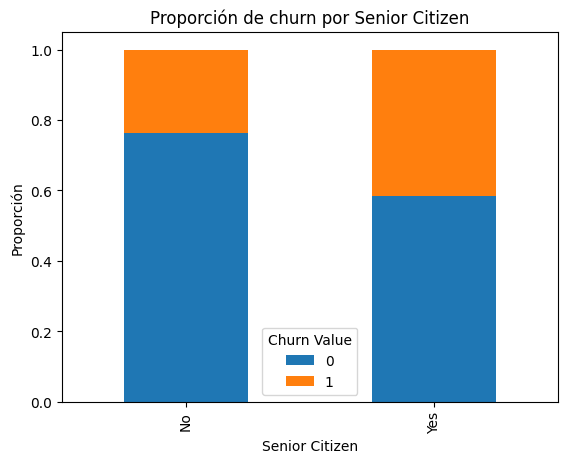

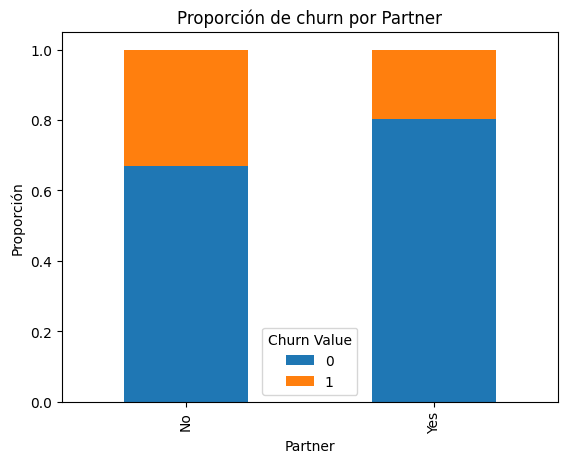

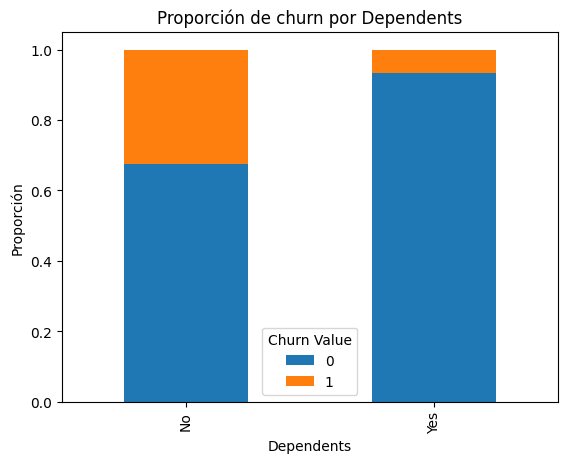

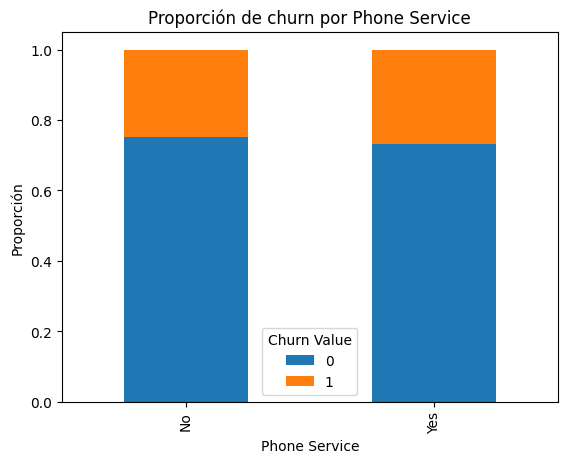

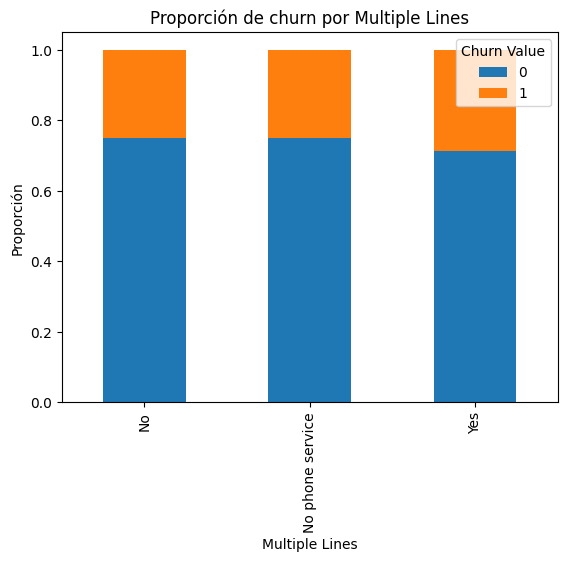

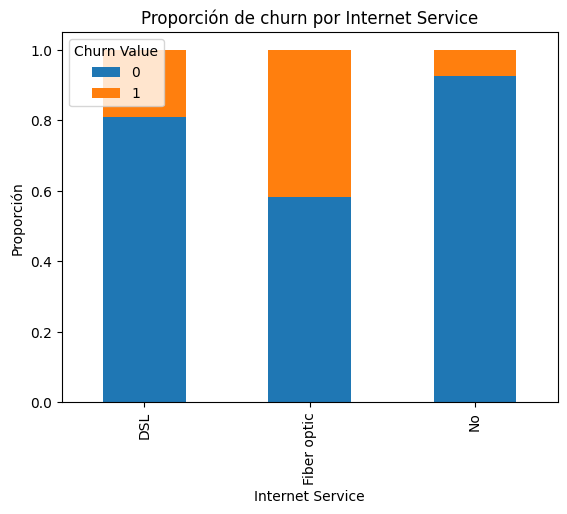

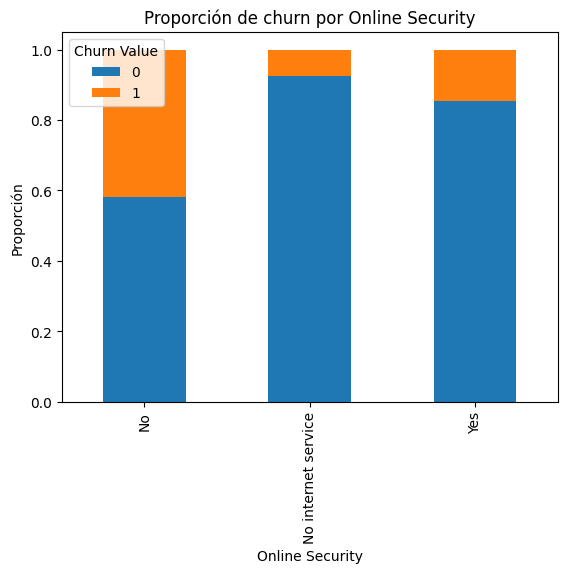

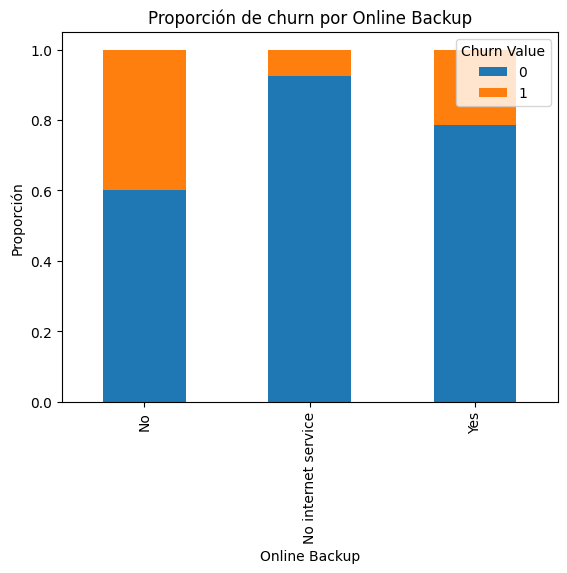

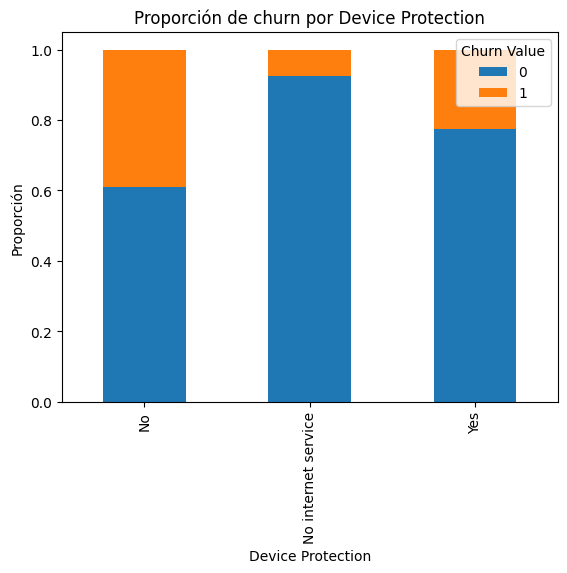

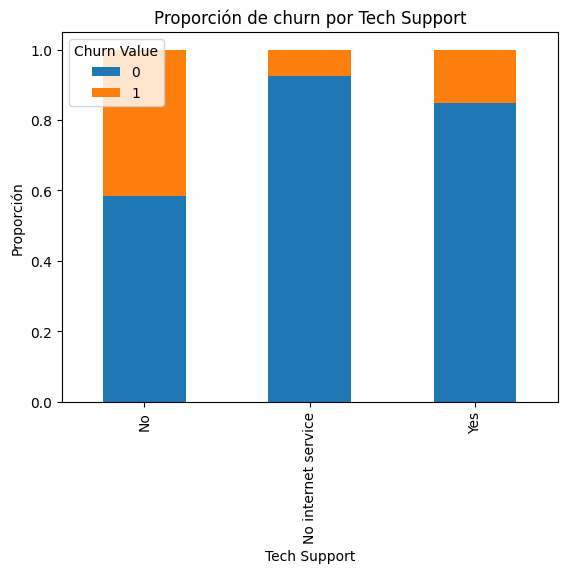

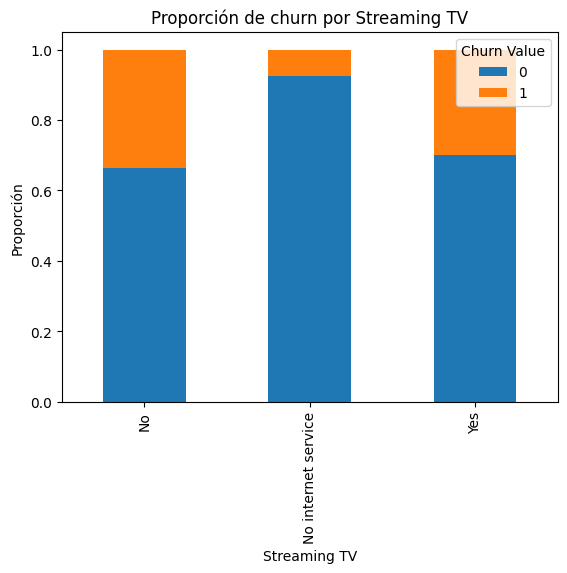

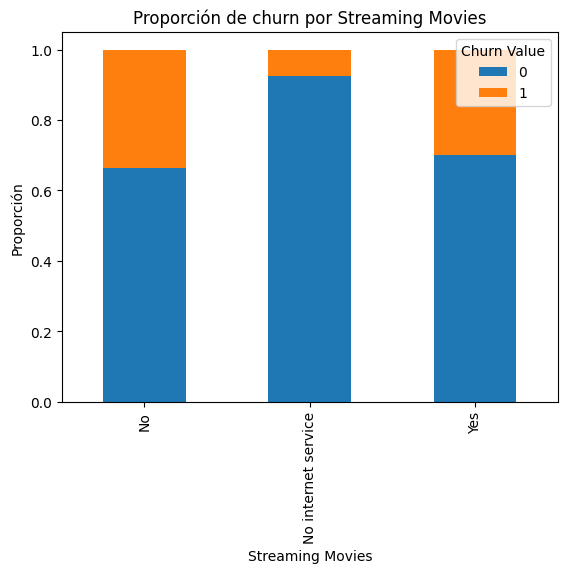

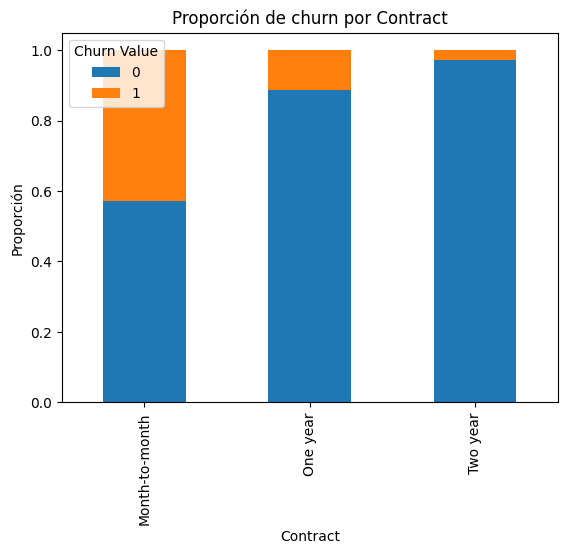

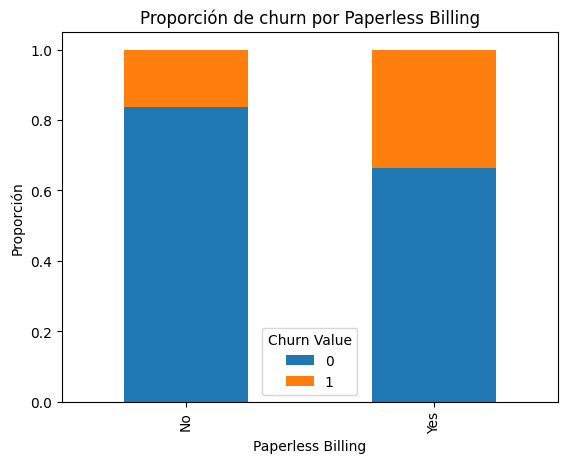

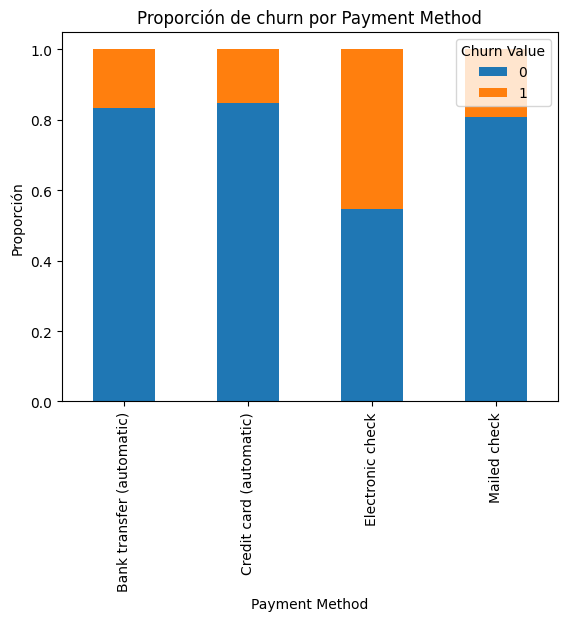

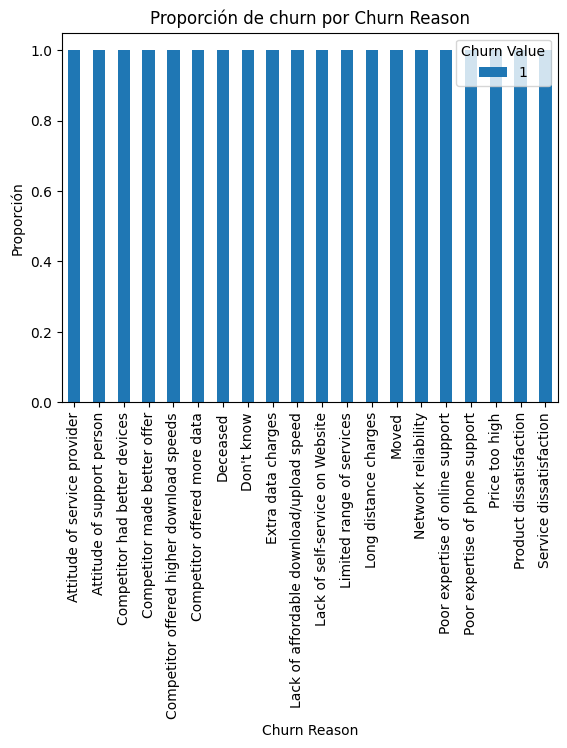

In [23]:
for var in cat_pred:
    tabla = pd.crosstab(df[var], df['Churn Value'], normalize='index')
    tabla.plot.bar(stacked=True)
    plt.title(f'Proporción de churn por {var}')
    plt.ylabel('Proporción')
    plt.show()


### Conclusión del análisis bivariado

- Las variables cuantitativas más relevantes suelen ser aquellas con mayor correlación con **Churn Value** y con diferencias más claras entre los grupos de churn y no churn.
- Las variables cualitativas con proporciones muy distintas entre categorías suelen ser buenas candidatas para modelado predictivo.
- Aquellas que presentan distribuciones muy parecidas entre categorías o baja variación no aportan mucho valor predictivo.

Con esta información se puede escoger un subconjunto de variables para construir modelos más simples e interpretables.
